In [1]:
import pandas as pd

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    "processed.cleveland.data",
    names=columns,
    na_values="?"
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [2]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(303, 14)
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [3]:
df["target"] = df["target"].apply(
    lambda x: 0 if x == 0 else 1
)

In [4]:
print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [5]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df["target"].value_counts())

(303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 

In [6]:
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
print(df["target"].value_counts())

print("\nPercentage:")
print(df["target"].value_counts(normalize=True) * 100)

target
0    164
1    139
Name: count, dtype: int64

Percentage:
target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


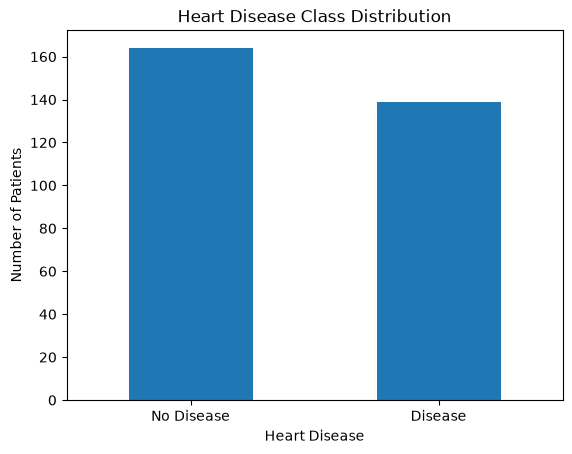

In [9]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Class Distribution")
plt.xticks([0, 1], ["No Disease", "Disease"], rotation=0)
plt.show()

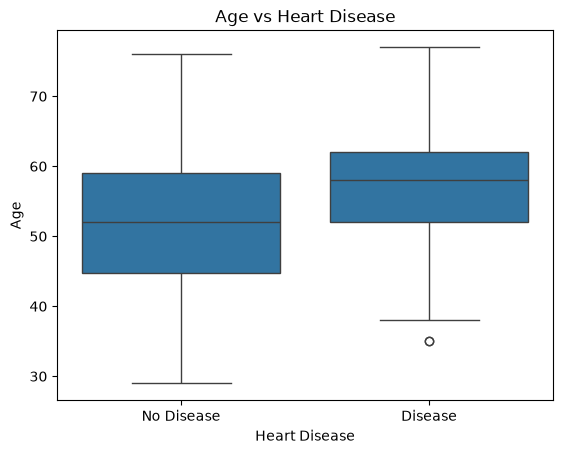

In [10]:
import seaborn as sns

sns.boxplot(x="target", y="age", data=df)

plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.title("Age vs Heart Disease")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

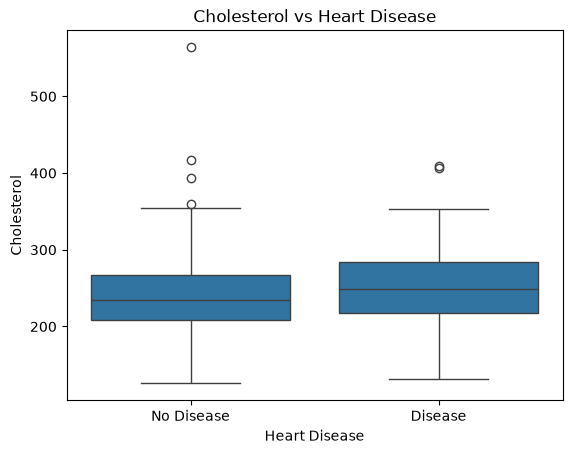

In [11]:
sns.boxplot(x="target", y="chol", data=df)

plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")
plt.title("Cholesterol vs Heart Disease")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

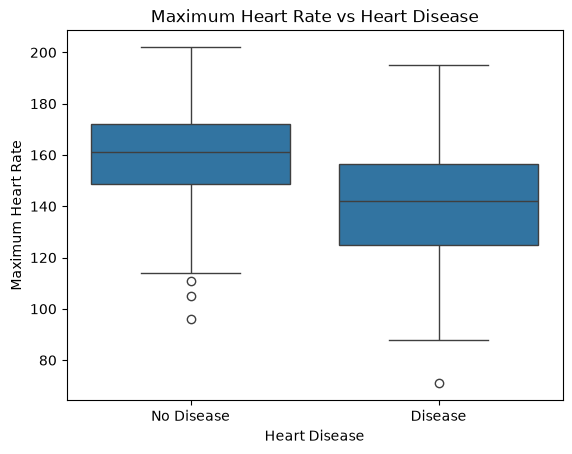

In [12]:
sns.boxplot(x="target", y="thalach", data=df)

plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")
plt.title("Maximum Heart Rate vs Heart Disease")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

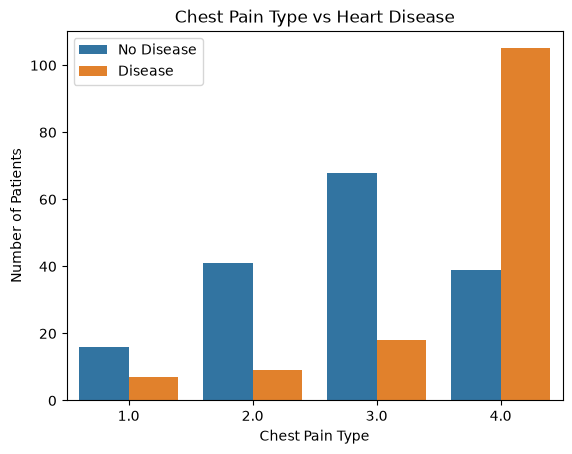

In [13]:
sns.countplot(x="cp", hue="target", data=df)

plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.title("Chest Pain Type vs Heart Disease")
plt.legend(["No Disease", "Disease"])
plt.show()

In [14]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


In [15]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (181, 13)
Validation: (61, 13)
Testing: (61, 13)


In [17]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [19]:
preprocessor.fit_transform(X_test)

array([[ 0.58771519,  0.63180914,  0.11661652, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.4894943 ,  1.10469697,  0.8666135 , ...,  1.        ,
         0.        ,  0.        ],
       [-1.37670272,  0.72638671, -0.26974556, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.78415699, -0.31396651,  0.63934169, ...,  0.        ,
         0.        ,  1.        ],
       [-0.19805197,  0.72638671,  1.43479303, ...,  0.        ,
         0.        ,  1.        ],
       [-0.78737734, -1.49618607, -0.701562  , ...,  1.        ,
         0.        ,  0.        ]], shape=(61, 28))

In [20]:
print("Training:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Testing:", X_test_processed.shape)

Training: (181, 28)
Validation: (61, 28)
Testing: (61, 28)


In [21]:
import numpy as np

X_train_processed = np.asarray(X_train_processed)
X_val_processed = np.asarray(X_val_processed)
X_test_processed = np.asarray(X_test_processed)

y_train = np.asarray(y_train)
y_val = np.asarray(y_val)
y_test = np.asarray(y_test)

In [22]:
print(type(X_train_processed))
print(X_train_processed.shape)
print(y_train.shape)

<class 'numpy.ndarray'>
(181, 28)
(181,)


In [23]:
print(X_train_processed.mean())
print(X_train_processed.std())

0.2857142857142857
0.6185895741317419


In [24]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [25]:
print(sigmoid(0))
print(sigmoid(2))
print(sigmoid(-2))

0.5
0.8807970779778823
0.11920292202211755


In [26]:
n_features = X_train_processed.shape[1]

weights = np.zeros(n_features)
bias = 0.0

print("Number of features:", n_features)
print("Weights shape:", weights.shape)
print("Bias:", bias)

Number of features: 28
Weights shape: (28,)
Bias: 0.0


In [27]:
def compute_loss(y, y_pred):
    epsilon = 1e-15
    
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    loss = -np.mean(
        y * np.log(y_pred) +
        (1 - y) * np.log(1 - y_pred)
    )
    
    return loss

In [28]:
def train_logistic_regression(X, y, learning_rate=0.01, iterations=1000):
    
    n_samples, n_features = X.shape
    
    weights = np.zeros(n_features)
    bias = 0.0
    
    loss_history = []
    
    for i in range(iterations):
        
        # Forward propagation
        z = np.dot(X, weights) + bias
        predictions = sigmoid(z)
        
        # Calculate loss
        loss = compute_loss(y, predictions)
        loss_history.append(loss)
        
        # Calculate gradients
        dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
        db = (1 / n_samples) * np.sum(predictions - y)
        
        # Update parameters
        weights -= learning_rate * dw
        bias -= learning_rate * db
    
    return weights, bias, loss_history

In [29]:
learning_rate = 0.01

weights, bias, loss_history = train_logistic_regression(
    X_train_processed,
    y_train,
    learning_rate=learning_rate,
    iterations=1000
)

print("Final Loss:", loss_history[-1])
print("Bias:", bias)
print("Weights shape:", weights.shape)

Final Loss: 0.390509928438291
Bias: -0.013495482792464401
Weights shape: (28,)


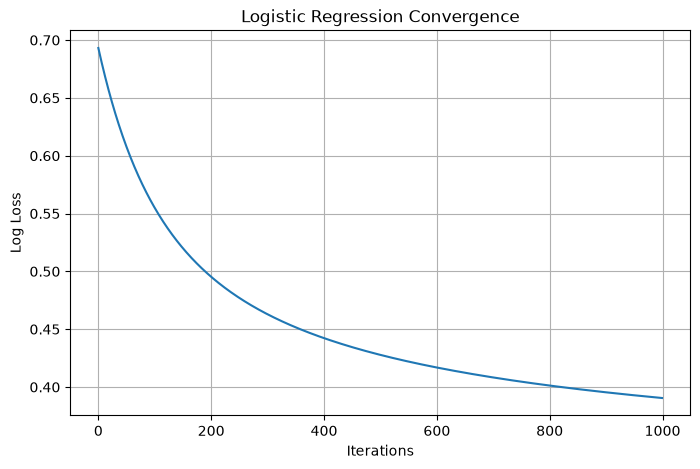

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Logistic Regression Convergence")

plt.grid()
plt.show()

In [31]:
def predict_probability(X, weights, bias):
    z = np.dot(X, weights) + bias
    return sigmoid(z)


def predict(X, weights, bias, threshold=0.5):
    probabilities = predict_probability(X, weights, bias)
    
    return (probabilities >= threshold).astype(int)

In [32]:
y_val_pred = predict(
    X_val_processed,
    weights,
    bias
)

print(y_val_pred[:20])

[0 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 0 0]


In [33]:
accuracy = np.mean(y_val_pred == y_val)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8032786885245902


In [34]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

results = {}

for lr in learning_rates:
    
    weights_lr, bias_lr, loss_history_lr = train_logistic_regression(
        X_train_processed,
        y_train,
        learning_rate=lr,
        iterations=1000
    )
    
    results[lr] = {
        "weights": weights_lr,
        "bias": bias_lr,
        "loss": loss_history_lr
    }
    
    print(
        f"Learning Rate: {lr} | "
        f"Final Loss: {loss_history_lr[-1]:.6f}"
    )

Learning Rate: 0.001 | Final Loss: 0.555112
Learning Rate: 0.01 | Final Loss: 0.390510
Learning Rate: 0.1 | Final Loss: 0.340630
Learning Rate: 1.0 | Final Loss: 0.337538


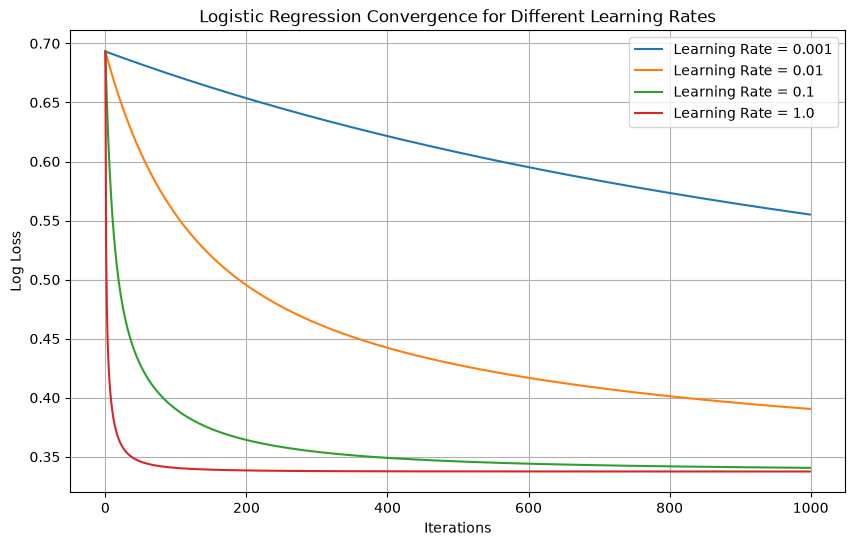

In [35]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    plt.plot(
        results[lr]["loss"],
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Logistic Regression Convergence for Different Learning Rates")
plt.legend()
plt.grid()
plt.show()

In [36]:
for lr in learning_rates:

    weights_lr = results[lr]["weights"]
    bias_lr = results[lr]["bias"]

    y_val_pred = predict(
        X_val_processed,
        weights_lr,
        bias_lr
    )

    accuracy = np.mean(y_val_pred == y_val)

    print(f"Learning Rate: {lr}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print()

Learning Rate: 0.001
Validation Accuracy: 0.8033

Learning Rate: 0.01
Validation Accuracy: 0.8033

Learning Rate: 0.1
Validation Accuracy: 0.8361

Learning Rate: 1.0
Validation Accuracy: 0.8852



In [37]:
best_lr = 0.1

In [38]:
best_lr = 0.1

final_weights, final_bias, final_loss = train_logistic_regression(
    X_train_processed,
    y_train,
    learning_rate=best_lr,
    iterations=1000
)

In [39]:
print("Initial Loss:", final_loss[0])
print("Final Loss:", final_loss[-1])

Initial Loss: 0.6931471805599453
Final Loss: 0.3406300150430982


In [40]:
y_test_probability = predict_probability(
    X_test_processed,
    final_weights,
    final_bias
)

In [41]:
y_test_pred = (
    y_test_probability >= 0.5
).astype(int)

In [42]:
print("Actual:   ", y_test[:20])
print("Predicted:", y_test_pred[:20])
print("Probability:", y_test_probability[:20])

Actual:    [0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1 0]
Predicted: [0 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0]
Probability: [0.0188779  0.14416822 0.49347524 0.96392877 0.03032353 0.67232027
 0.17276491 0.0997485  0.01457309 0.96646899 0.1524486  0.03935606
 0.82437058 0.90683359 0.75946477 0.21690787 0.58825488 0.02845656
 0.63844589 0.05296832]


In [43]:
TP = np.sum((y_test == 1) & (y_test_pred == 1))
TN = np.sum((y_test == 0) & (y_test_pred == 0))
FP = np.sum((y_test == 0) & (y_test_pred == 1))
FN = np.sum((y_test == 1) & (y_test_pred == 0))

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 23
TN: 31
FP: 2
FN: 5


In [44]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0

recall = TP / (TP + FN) if (TP + FN) != 0 else 0

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) != 0
    else 0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8852
Precision: 0.9200
Recall   : 0.8214
F1 Score : 0.8679


In [45]:
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

print(confusion_matrix)

[[31  2]
 [ 5 23]]


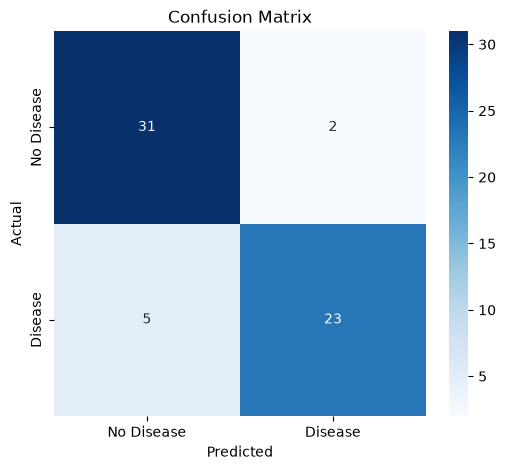

In [46]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
y_test_probability

array([0.0188779 , 0.14416822, 0.49347524, 0.96392877, 0.03032353,
       0.67232027, 0.17276491, 0.0997485 , 0.01457309, 0.96646899,
       0.1524486 , 0.03935606, 0.82437058, 0.90683359, 0.75946477,
       0.21690787, 0.58825488, 0.02845656, 0.63844589, 0.05296832,
       0.03680935, 0.37012288, 0.44771702, 0.01466912, 0.30824206,
       0.04123436, 0.48052833, 0.10703561, 0.42948276, 0.04753573,
       0.94256859, 0.75651601, 0.98826873, 0.97374636, 0.47777808,
       0.01286777, 0.06426696, 0.99046573, 0.98515162, 0.03047597,
       0.94886164, 0.02096137, 0.9933919 , 0.85733868, 0.10122355,
       0.91845276, 0.79669087, 0.35007784, 0.04878027, 0.42186179,
       0.95453211, 0.02949486, 0.98102822, 0.24907342, 0.40041571,
       0.63921564, 0.74619628, 0.93397269, 0.64988141, 0.24341931,
       0.01432107])

In [48]:
thresholds = np.linspace(0, 1, 101)

tpr_values = []
fpr_values = []

for threshold in thresholds:

    predictions = (
        y_test_probability >= threshold
    ).astype(int)

    TP = np.sum((y_test == 1) & (predictions == 1))
    TN = np.sum((y_test == 0) & (predictions == 0))
    FP = np.sum((y_test == 0) & (predictions == 1))
    FN = np.sum((y_test == 1) & (predictions == 0))

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    tpr_values.append(TPR)
    fpr_values.append(FPR)

In [49]:
auc = np.trapezoid(
    tpr_values,
    fpr_values
)

print("AUC:", auc)

AUC: -0.9512987012987012


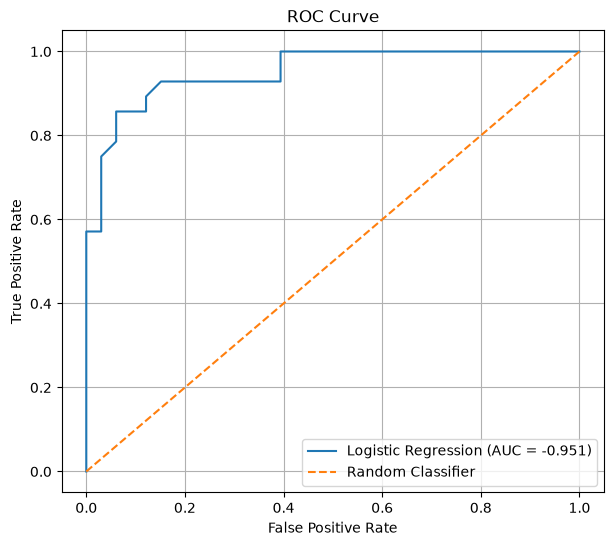

In [50]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_values,
    tpr_values,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [52]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 28
['num__age' 'num__trestbps' 'num__chol' 'num__thalach' 'num__oldpeak'
 'cat__sex_0.0' 'cat__sex_1.0' 'cat__cp_1.0' 'cat__cp_2.0' 'cat__cp_3.0'
 'cat__cp_4.0' 'cat__fbs_0.0' 'cat__fbs_1.0' 'cat__restecg_0.0'
 'cat__restecg_1.0' 'cat__restecg_2.0' 'cat__exang_0.0' 'cat__exang_1.0'
 'cat__slope_1.0' 'cat__slope_2.0' 'cat__slope_3.0' 'cat__ca_0.0'
 'cat__ca_1.0' 'cat__ca_2.0' 'cat__ca_3.0' 'cat__thal_3.0' 'cat__thal_6.0'
 'cat__thal_7.0']


In [53]:
coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": final_weights
})

coefficient_df["abs_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coefficient_df.head(10)

,feature,coefficient,abs_coefficient
21,cat__ca_0.0,-1.551742,1.551742
10,cat__cp_4.0,1.230900,1.230900
9,cat__cp_3.0,-0.784525,0.784525
25,cat__thal_3.0,-0.653075,0.653075
5,cat__sex_0.0,-0.637904,0.637904
27,cat__thal_7.0,0.630447,0.630447
6,cat__sex_1.0,0.624264,0.624264
23,cat__ca_2.0,0.581614,0.581614
24,cat__ca_3.0,0.514124,0.514124
7,cat__cp_1.0,-0.477936,0.477936


In [54]:
positive_features = coefficient_df[
    coefficient_df["coefficient"] > 0
].head(10)

print(positive_features)

           feature  coefficient  abs_coefficient
10     cat__cp_4.0     1.230900         1.230900
27   cat__thal_7.0     0.630447         0.630447
6     cat__sex_1.0     0.624264         0.624264
23     cat__ca_2.0     0.581614         0.581614
24     cat__ca_3.0     0.514124         0.514124
19  cat__slope_2.0     0.460307         0.460307
22     cat__ca_1.0     0.442364         0.442364
17  cat__exang_1.0     0.375747         0.375747
11    cat__fbs_0.0     0.306104         0.306104
1    num__trestbps     0.198248         0.198248


In [55]:
negative_features = coefficient_df[
    coefficient_df["coefficient"] < 0
].sort_values(
    "coefficient"
).head(10)

print(negative_features)

             feature  coefficient  abs_coefficient
21       cat__ca_0.0    -1.551742         1.551742
9        cat__cp_3.0    -0.784525         0.784525
25     cat__thal_3.0    -0.653075         0.653075
5       cat__sex_0.0    -0.637904         0.637904
7        cat__cp_1.0    -0.477936         0.477936
18    cat__slope_1.0    -0.436752         0.436752
16    cat__exang_0.0    -0.389387         0.389387
12      cat__fbs_1.0    -0.319744         0.319744
3       num__thalach    -0.257209         0.257209
13  cat__restecg_0.0    -0.100325         0.100325


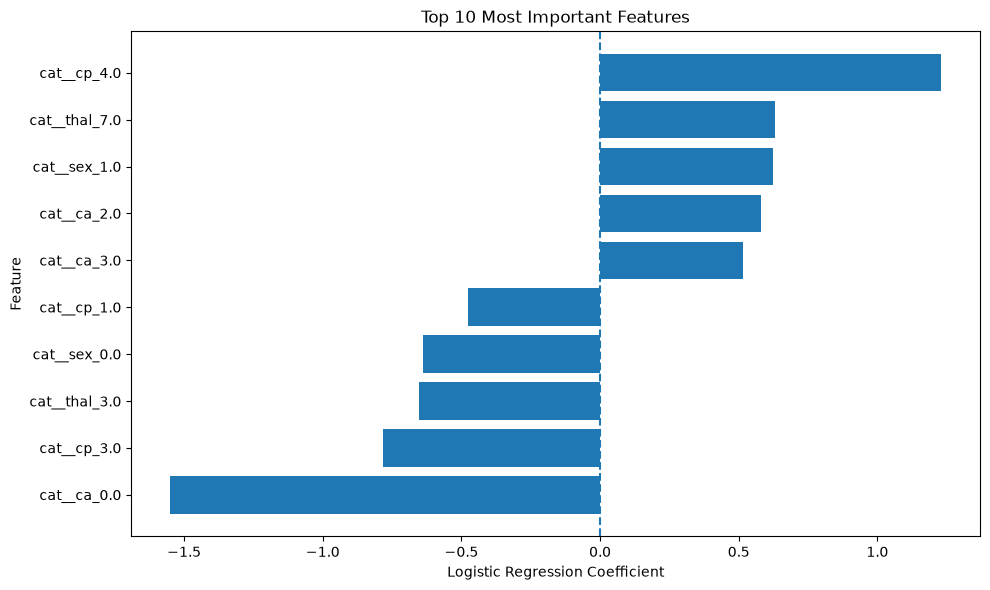

In [56]:
top10 = coefficient_df.head(10).sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["feature"],
    top10["coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.axvline(
    x=0,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [57]:
coefficient_df["clean_feature"] = (
    coefficient_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coefficient_df.head(10)

,feature,coefficient,abs_coefficient,clean_feature
21,cat__ca_0.0,-1.551742,1.551742,ca_0.0
10,cat__cp_4.0,1.230900,1.230900,cp_4.0
9,cat__cp_3.0,-0.784525,0.784525,cp_3.0
25,cat__thal_3.0,-0.653075,0.653075,thal_3.0
5,cat__sex_0.0,-0.637904,0.637904,sex_0.0
27,cat__thal_7.0,0.630447,0.630447,thal_7.0
6,cat__sex_1.0,0.624264,0.624264,sex_1.0
23,cat__ca_2.0,0.581614,0.581614,ca_2.0
24,cat__ca_3.0,0.514124,0.514124,ca_3.0
7,cat__cp_1.0,-0.477936,0.477936,cp_1.0


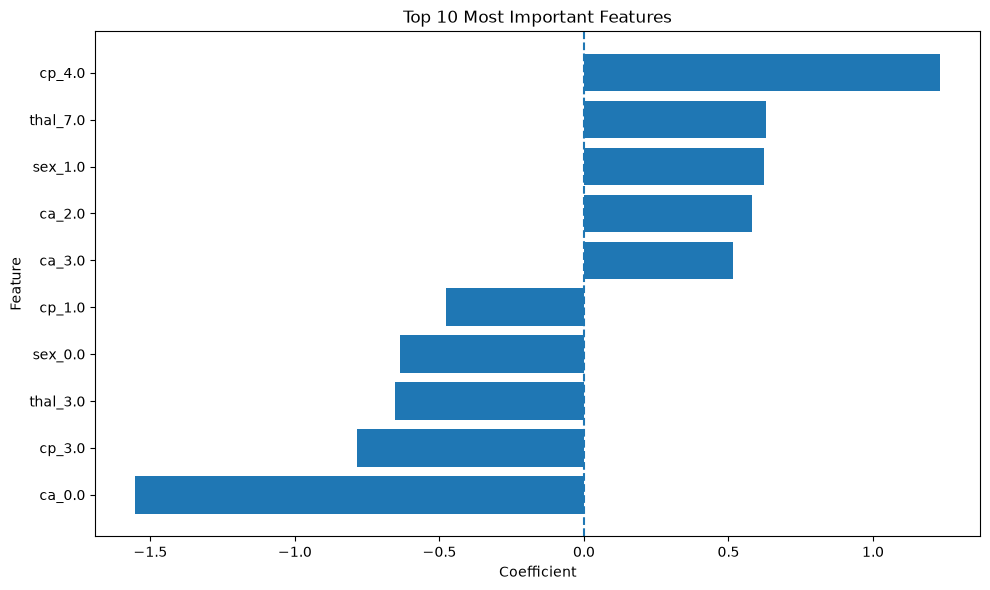

In [58]:
top10 = coefficient_df.head(10).sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["clean_feature"],
    top10["coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.axvline(
    x=0,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [59]:
coefficient_df["odds_ratio"] = np.exp(
    coefficient_df["coefficient"]
)

In [60]:
coefficient_df[
    ["clean_feature", "coefficient", "odds_ratio"]
].head(10)

,clean_feature,coefficient,odds_ratio
21,ca_0.0,-1.551742,0.211879
10,cp_4.0,1.230900,3.424312
9,cp_3.0,-0.784525,0.456336
25,thal_3.0,-0.653075,0.520443
5,sex_0.0,-0.637904,0.528399
27,thal_7.0,0.630447,1.878450
6,sex_1.0,0.624264,1.866872
23,ca_2.0,0.581614,1.788924
24,ca_3.0,0.514124,1.672173
7,cp_1.0,-0.477936,0.620062


In [ ]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

metrics_df

,Metric,Value
0,Accuracy,0.885246
1,Precision,0.920000
2,Recall,0.821429
3,F1 Score,0.867925
4,ROC-AUC,-0.951299
